In [23]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.TransformerBottleneck_model import TransformerBottleneck_model
from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms
from src.utils.test_nb_functions import zeros_poles_freq_to_positions, plot_responses

In [24]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
    v = torch.backends.cudnn.version()
    print(f"cuDNN: {v//10000}.{(v%1000)//100}.{v%100}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6
cuDNN: 9.5.1


Настройки общие.

In [25]:
threshold = 0.5

Пути к каталогам.

In [26]:
model_name = 'TransformerBottleneck-model' #_halfwindow_8

config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{model_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]

Импорт модели.

In [27]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

model = TransformerBottleneck_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
    net = model,
    checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
    device = device
    )

model.eval()

transform = ConversionTransforms(
    num_iter=2,
    return_input=False
    )

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model.pth


Перечень csv-файлов.

In [28]:
sample_file_name_list = None
ext = '.csv'

sample_dir = Path("test_samples")

if sample_file_name_list is None:
    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]

In [29]:
masks_path = sample_dir/ "test_masks.json"
assert masks_path.exists(), f"Config not found: {masks_path}"
with open(masks_path, "r") as f:
    masks_full = json.load(f)
masks_list = []
for sample_file_name in sample_file_name_list:
    masks_list.append(masks_full[sample_file_name])

for masks in masks_list:
    masks.pop('zero_poles')

Чтение данных и инференс.

In [30]:
data_list = []
for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > threshold).float().detach().cpu().numpy())

Визуализация.

In [31]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 9,
    'fig_width': 8,
    'fig_height': 6,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'legend_framealpha': 0.8,
    'legend_loc': 'best',
    'plots': [
        {
            'ylabel': 'Амплитуда, дБ', # 'Magnitude, dB'
            'xlabel': None, #'Частота, Гц', # 'Frequency, Hz', 'Samples',
            'xscale': 'log', # 'log', 'linear',
            'arg_key': 'freq', # 'freq', 'samples',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Фаза, град.', # 'Phase, deg'
            'xlabel': 'Частота, Гц',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph'
        }
    ],
    'masks': [
        {'label': 'left_poles',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_poles', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zeros',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zeros', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

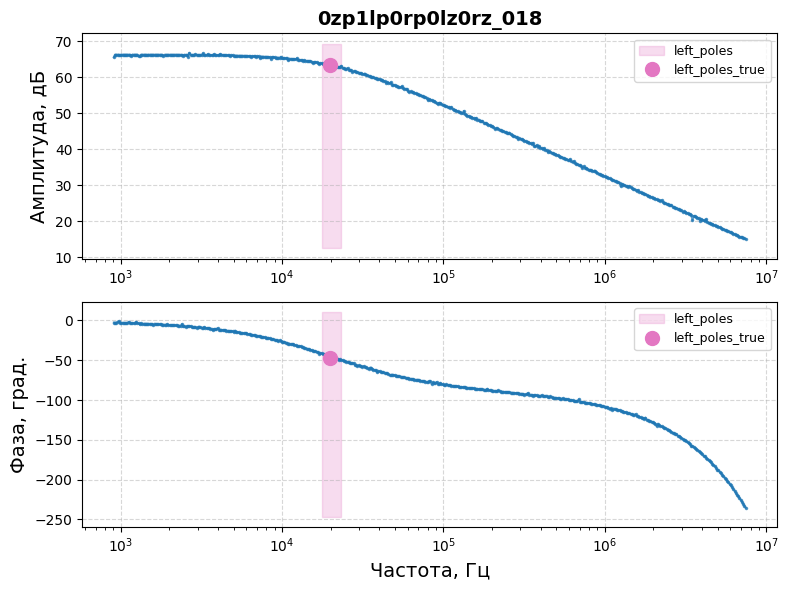

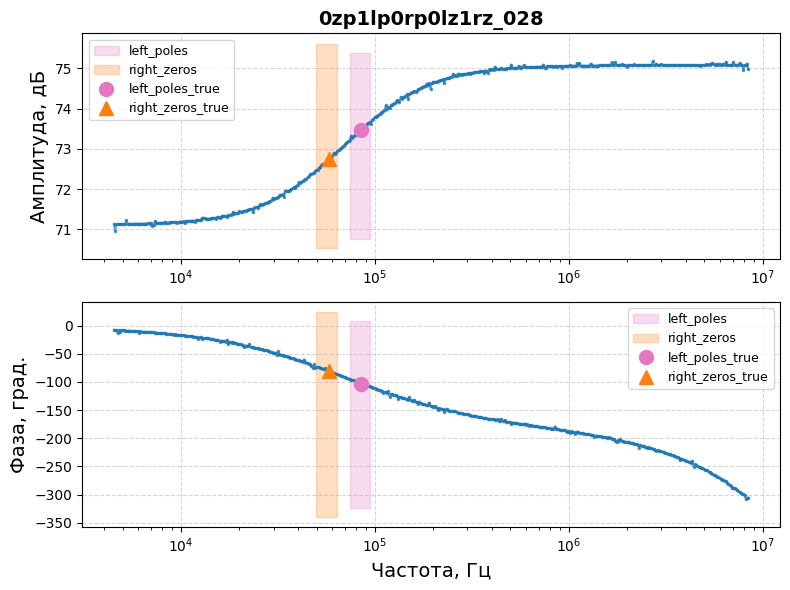

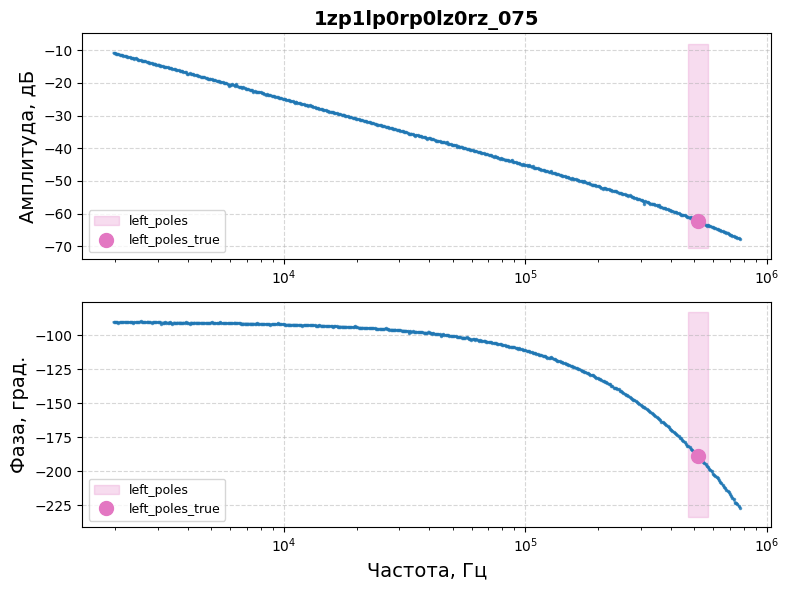

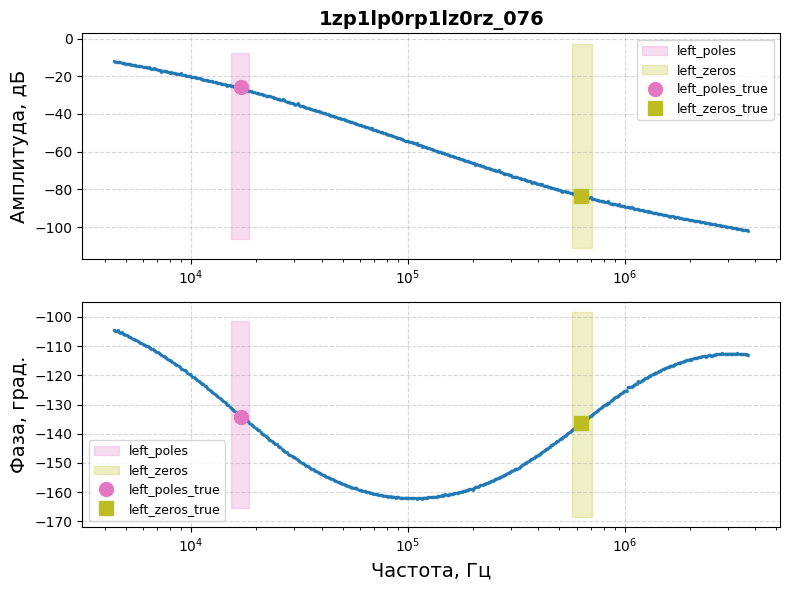

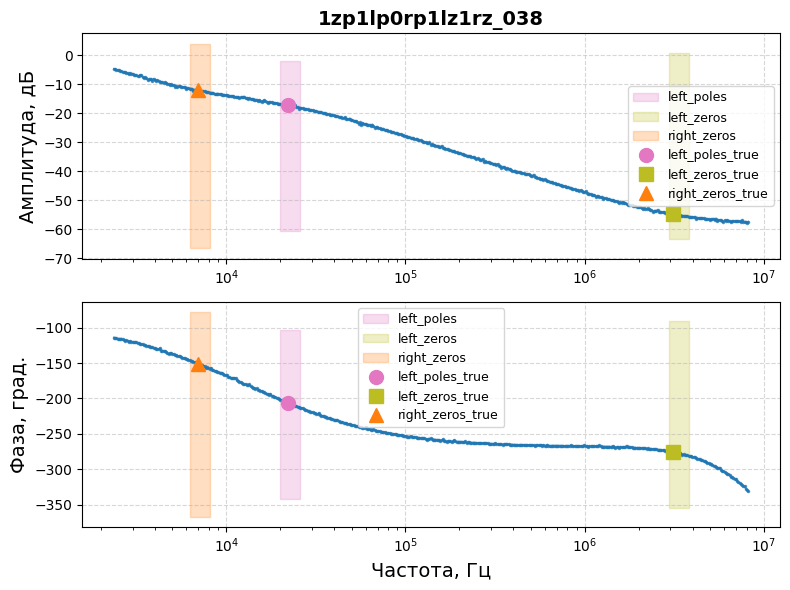

In [32]:
freq_masks_list = [
    {
    "left_poles": [20e3],
    "right_poles": [],
    "left_zeros": [],
    "right_zeros": []
    },
    {
    "left_poles": [85e3],
    "right_poles": [],
    "left_zeros": [],
    "right_zeros": [58e3]
    },
    {
    "left_poles": [520e3],
    "right_poles": [],
    "left_zeros": [],
    "right_zeros": []
    },
    {
    "left_poles": [17e3],
    "right_poles": [],
    "left_zeros": [630e3],
    "right_zeros": []
    },
    {
    "left_poles": [22e3],
    "right_poles": [],
    "left_zeros": [3.1e6],
    "right_zeros": [7e3]
    }
]

for data, freq_masks, predictions, sample_file_name in zip(data_list, freq_masks_list, predictions_list, sample_file_name_list):
    masks = zeros_poles_freq_to_positions(zeros_poles_freq_dict=freq_masks, freq=data[0,:])
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        title=sample_file_name,
        regions=predictions,
        masks=masks
        )

# Дополнительный тест

Чтение данных и инференс.

In [33]:
sample_file_name_list = ["LPF.csv"]

sample_dir = Path("test_samples/extra")

if sample_file_name_list is None:
    sample_file_name_list = [f.name for f in sample_dir.iterdir() if f.is_file()]
    
data_list = []

for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / sample_file_name, delimiter=',', skiprows=1).T)

fp: 2134.0888
fz: 41380.2852


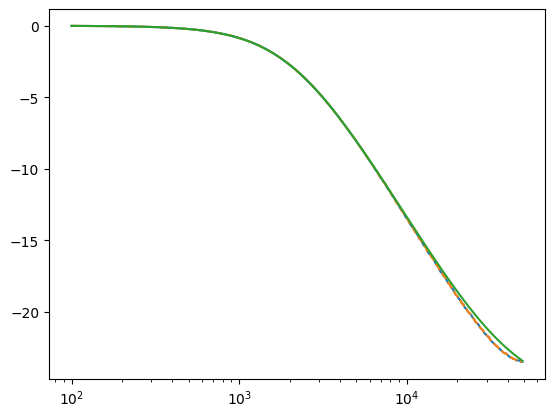

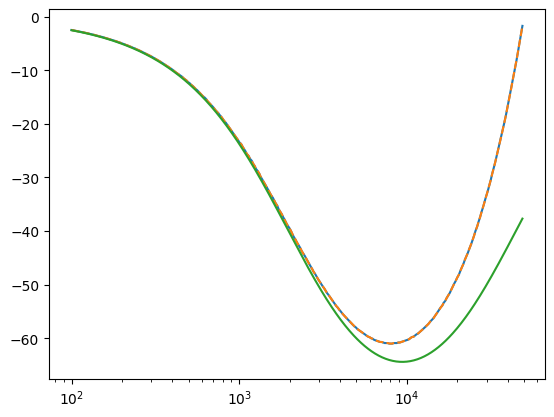

In [34]:
from matplotlib import pyplot as plt

freq = data_list[0][0]
y_stack = np.array([data_list[0][1], data_list[0][2]])

freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
y_new = np.array([np.interp(freq_log, freq, y) for y in y_stack])

fs = 100000
k = 12566.3706143592 / fs
fp = 2*k*fs /(2-k) / (2*np.pi)
fz = fs / np.pi
print('fp:', np.round(fp, 4))
#wz = (2*fs) * np.tan(2*np.pi*fz/fs / 2)
#wp = (2*fs) * np.tan(2*np.pi*fp/fs / 2)
wz = 2*np.pi*fz*1.3
wp = 2*np.pi*fp

print('fz:', np.round(wz/(2*np.pi), 4))

s = 1j * freq_log * 2 * np.pi
gain_complex = (1 + s/wz)/(1 + s/wp)
mag_db = 20*np.log10(np.abs(gain_complex))
ph_deg = 180 / np.pi * np.unwrap(np.angle(gain_complex))

data_list = [np.column_stack([freq_log, y_new[0], y_new[1]]).T]

plt.plot(freq, y_stack[0])
plt.xscale('log')
plt.plot(freq_log, y_new[0], '--')
plt.plot(freq_log, mag_db)
plt.show()

plt.plot(freq, y_stack[1])
plt.xscale('log')
plt.plot(freq_log, y_new[1], '--')
plt.plot(freq_log, ph_deg)
plt.show()

In [35]:
predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > threshold).float().detach().cpu().numpy())

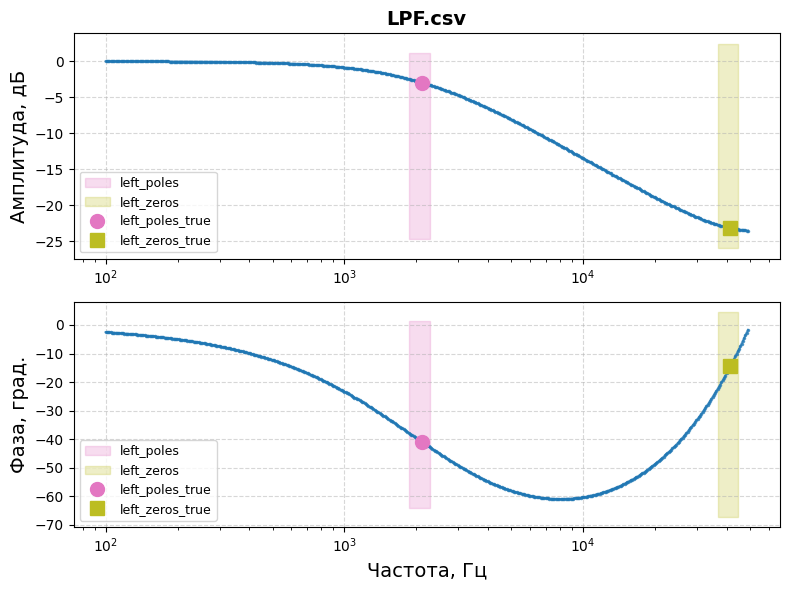

In [37]:
freq_masks_list = [{
    "left_poles": [wp/(2*np.pi)],
    "right_poles": [],
    "left_zeros": [wz/(2*np.pi)],
    "right_zeros": []
    }
]

for data, freq_masks, predictions, sample_file_name in zip(data_list, freq_masks_list, predictions_list, sample_file_name_list):
    masks = zeros_poles_freq_to_positions(zeros_poles_freq_dict=freq_masks, freq=data[0,:])
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        title=sample_file_name,
        regions=predictions,
        masks=masks
        )